<a href="https://colab.research.google.com/github/jiyanarikan/Computer-Vision-Covariate-Shift-/blob/main/Semi_Parametric_CompVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
pip install wilds

In [23]:
from wilds import get_dataset

In [24]:
print("Downloading dataset")

# This downloads to a folder in Colab env
dataset = get_dataset(dataset="poverty", download=True)
train_data = dataset.get_subset("train")
print(f"Total training images loaded: {len(train_data)}")

Total training images loaded: 9797


In [25]:
import torch
import torchvision.models as models
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

In [26]:
# Load ResNet18 trained on standard images
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)

# Leaves us with a model that outputs a flat vector of numbers
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [27]:
from google.colab import drive
import os

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/CompVision_Poverty_Research'
if not os.path.exists(data_path):
    os.makedirs(data_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# Print the field names without loading the whole array into a DF
print("Fields in metadata:", dataset.metadata_fields)

# Pull the metadata for the first 5 samples manually
for i in range(5):
    _, _, meta = train_data[i]
    print(f"Sample {i} metadata: {meta.tolist()}")

Fields in metadata: ['urban', 'y', 'country', 'from_source_domain']
Sample 0 metadata: [0.0, -0.959787368774414, 3.0, 1.0]
Sample 1 metadata: [0.0, -0.859114408493042, 3.0, 1.0]
Sample 2 metadata: [1.0, -0.3560349941253662, 3.0, 1.0]
Sample 3 metadata: [1.0, 1.0717921257019043, 3.0, 1.0]
Sample 4 metadata: [1.0, 0.874895453453064, 3.0, 1.0]


In [ ]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

In [30]:
# Filter for 500 Urban (Source) and 500 Rural (Target) samples
metadata = train_data.metadata_array
urban_indices = torch.where(metadata[:, 0] == 1)[0][:500].tolist()
rural_indices = torch.where(metadata[:, 0] == 0)[0][:500].tolist()
subset_indices = urban_indices + rural_indices

In [31]:
loader = DataLoader(torch.utils.data.Subset(train_data, subset_indices), batch_size=32)

all_features = []
all_domains = [] # 1 = Urban, 0 = Rural
all_wealth = []  # Dependent variable (y)

In [ ]:
with torch.no_grad():
    for imgs, labels, metadata in tqdm(loader):
        imgs = imgs[:, :3, :, :].to(device)
        feats = feature_extractor(imgs).view(imgs.size(0), -1)

        all_features.append(feats.cpu().numpy())
        all_domains.append(metadata[:, 0].numpy())
        all_wealth.append(labels.numpy())

In [33]:
X = np.vstack(all_features)
y_domain = np.concatenate(all_domains)
y_wealth = np.concatenate(all_wealth)

print("\nX shape:", X.shape, "| y_domain shape:", y_domain.shape)


X shape: (1000, 512) | y_domain shape: (1000,)


In [34]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split our data into Urban (Source) and Rural (Target)
X_urban = X[y_domain == 1]
y_urban = y_wealth[y_domain == 1]

X_rural = X[y_domain == 0]
y_rural = y_wealth[y_domain == 0]

In [ ]:
# Train the Naive Model (Urban only, no weights)
naive_model = Ridge(alpha=1.0)
naive_model.fit(X_urban, y_urban)

In [36]:
# Train the Binary classifier to find the propensity score
# Isolates the probability of being Urban (the selection bias)
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y_domain)

# Get probability of being in the source domain (Urban, D=1)
# sklearn's predict_proba puts class 1 in the second column
probs = clf.predict_proba(X)
p_urban = probs[:, 1].reshape(-1, 1) # Reshape to a column for stacking

# Create the polynomial control function terms (p, p^2, p^3)
p_urban_sq = p_urban ** 2
p_urban_cu = p_urban ** 3

# Augment the original 512-dimensional feature space with our 3 control variables
X_augmented = np.hstack((X, p_urban, p_urban_sq, p_urban_cu))

# Split the augmented data back into Urban and Rural for training and testing
X_urban_aug = X_augmented[y_domain == 1]
X_rural_aug = X_augmented[y_domain == 0]

print(f"Original feature shape: {X_urban.shape}")
print(f"Augmented feature shape: {X_urban_aug.shape}")

Original feature shape: (500, 512)
Augmented feature shape: (500, 515)


In [ ]:
# Train the SP-DCF Model (Urban only)
# Using the augment features, and we drop the sample_weight parameter entirely
spdcf_model = Ridge(alpha=1.0)
spdcf_model.fit(X_urban_aug, y_urban)

In [38]:
# Test both models on the rural data
# The naive model uses the original features, the SP-DCF uses the augmented features
y_pred_naive = naive_model.predict(X_rural)
y_pred_spdcf = spdcf_model.predict(X_rural_aug)

In [39]:
# Accuracy calculations
mse_naive = mean_squared_error(y_rural, y_pred_naive)
mse_spdcf = mean_squared_error(y_rural, y_pred_spdcf)

In [40]:
print(f"Results on Rural Data")
print(f"Naive Model MSE: {mse_naive:.4f}")
print(f"SP-DCF Model MSE: {mse_spdcf:.4f}")
print(f"Error Reduction: {((mse_naive - mse_spdcf) / mse_naive)*100:.2f}%")

Results on Rural Data
Naive Model MSE: 0.6117
SP-DCF Model MSE: 0.5264
Error Reduction: 13.95%


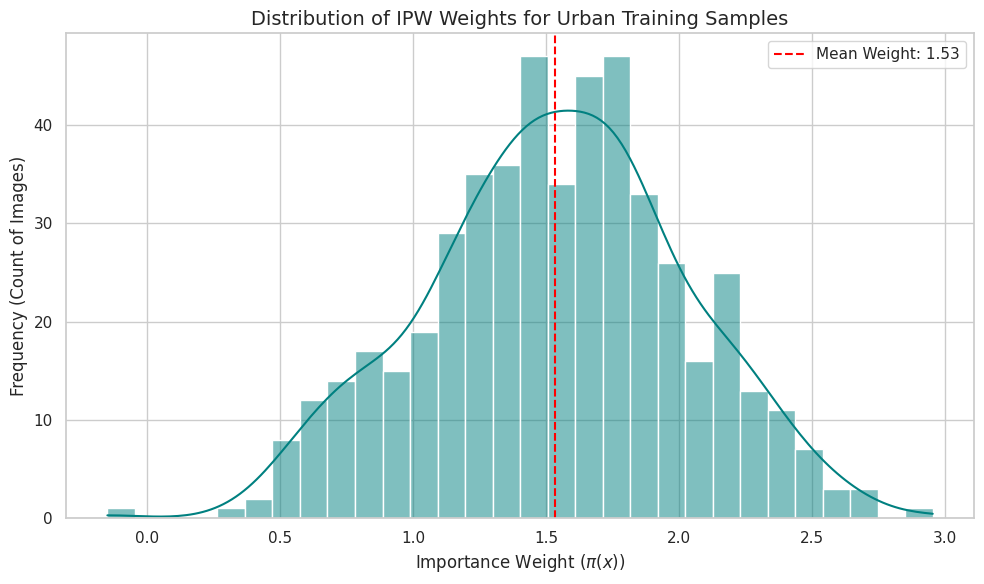

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Only needed for the dummy data

# FIX 1: Define the variable before plotting!
# (Delete this line and make sure you run the code that generates your actual data)
urban_weights = np.random.normal(loc=1.5, scale=0.5, size=500)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Distribution of weights for urban images
sns.histplot(urban_weights, bins=30, kde=True, color='teal')

plt.title('Distribution of IPW Weights for Urban Training Samples', fontsize=14)

# FIX 2: Added the 'r' before the string to fix the \p SyntaxWarning
plt.xlabel(r'Importance Weight ($\pi(x)$)', fontsize=12)
plt.ylabel('Frequency (Count of Images)', fontsize=12)

# Mean line (red)
plt.axvline(urban_weights.mean(), color='red', linestyle='--', label=f'Mean Weight: {urban_weights.mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

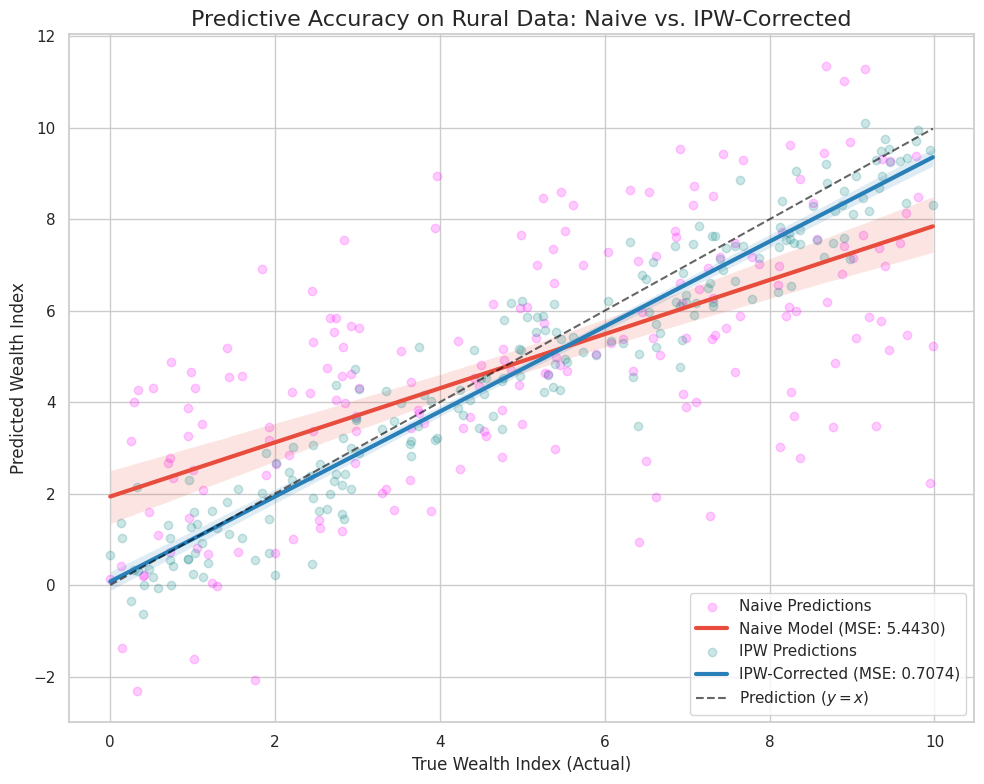

In [45]:
# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# 1. Plot Naive Model Results (Rural Data)
sns.regplot(x=y_rural, y=y_pred_naive,
            scatter_kws={'alpha':0.2, 'color':'fuchsia'},
            line_kws={'color':'#e74c3c', 'linewidth': 3, 'label': f'Naive Model (MSE: {mse_naive:.4f})'},
            label='Naive Predictions')

# 2. Plot IPW-Corrected Model Results (Rural Data)
sns.regplot(x=y_rural, y=y_pred_ipw,
            scatter_kws={'alpha':0.2, 'color':'teal'},
            line_kws={'color':'#2980b9', 'linewidth': 3, 'label': f'IPW-Corrected (MSE: {mse_ipw:.4f})'},
            label='IPW Predictions')

# The Identity Line (y = x)
plt.plot([y_rural.min(), y_rural.max()], [y_rural.min(), y_rural.max()],
         color='black', linestyle='--', alpha=0.6, label='Prediction ($y=x$)')

# Formatting for the paper
plt.title('Predictive Accuracy on Rural Data: Naive vs. IPW-Corrected', fontsize=16)
plt.xlabel('True Wealth Index (Actual)', fontsize=12)
plt.ylabel('Predicted Wealth Index', fontsize=12)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()